# 01. PreEDA

## Digital Burnout International Dataset

- Khảo sát dữ liệu thô.
- Hiểu cấu trúc và đặc điểm dữ liệu.
- Đánh giá chất lượng dữ liệu ban đầu.
- Kiểm tra mức độ hiện diện của các chỉ báo liên quan Digital Burnout.
- Hỗ trợ xây dựng Digital Burnout Indicator Framework (DBI).
- Chuẩn bị đầu vào cho bước Cleaning & Preprocessing.

## Import thư viện
Nhập các thư viện cần thiết

In [5]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Dataset

Phần này dùng để tải dataset thô từ thư mục `data/raw`.

Dataset được sử dụng trong notebook này là dataset về Digital Burnout và Productivity.

In [6]:
file_path = "../../data/raw/digital_burnout_productivity_dataset_5M.csv"

df = pd.read_csv(file_path)

print("Dữ liệu đã được tải thành công.")
print(df.shape)

Dữ liệu đã được tải thành công.
(5000000, 34)


## 2. Dataset Overview

Phần này nhằm khảo sát tổng quan dataset:

- Kích thước dữ liệu
- Cấu trúc dữ liệu
- Kiểu dữ liệu
- Số lượng biến
- Ví dụ các bản ghi đầu tiên

Kết quả giúp hiểu dữ liệu trước khi tiến hành các bước tiền xử lý.

In [9]:
# Dataset overview

print("Dataset shape:")
print(df.shape)

print("\nDataset information:")
display(df.info())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Dataset shape:
(5000000, 34)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 34 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  int64  
 1   age                      int64  
 2   occupation               object 
 3   work_mode                object 
 4   device_usage_type        object 
 5   daily_screen_time        float64
 6   social_media_hours       float64
 7   doomscrolling_duration   float64
 8   app_switch_frequency     int64  
 9   notification_count       int64  
 10  smartphone_unlocks       int64  
 11  late_night_device_usage  int64  
 12  focus_sessions           int64  
 13  deep_work_hours          float64
 14  distraction_frequency    int64  
 15  task_completion_rate     int64  
 16  concentration_score      int64  
 17  sleep_hours              float64
 18  sleep_quality            int64  
 19  caffeine_intake          int64  


None


First 5 rows:


,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
0,1,56,Content Creator,Office,Entertainment-Centric,8.8,5.0,1.2,41,112,49,1,3,6.0,67,92,2,5.9,10,6,1.6,10,5,2.8,3,4,8.0,10,4,8,Balanced,46,100,High
1,2,46,Student,Hybrid,Work-Centric,10.3,2.2,2.4,119,168,153,1,9,4.6,75,74,3,5.6,7,5,1.1,5,10,3.2,7,6,5.0,7,9,7,Balanced,57,96,High
2,3,32,Software Engineer,Remote,Balanced,6.5,4.6,1.0,121,199,234,1,5,NaN,70,96,7,5.5,8,6,1.1,4,1,2.3,9,6,8.0,5,2,6,Balanced,29,79,High
3,4,25,Designer,Office,Balanced,9.6,1.2,0.1,85,122,177,1,9,2.9,107,60,3,6.1,5,1,1.7,1,4,3.8,10,5,6.0,4,5,3,Burnout,57,63,Medium
4,5,38,Analyst,Hybrid,Work-Centric,13.3,1.6,1.9,221,73,91,1,9,2.8,72,73,9,7.9,1,3,1.8,4,8,3.0,1,1,4.0,7,9,7,Focused,64,89,High



Last 5 rows:


,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
4999995,4999996,45,Manager,Hybrid,Entertainment-Centric,8.0,4.2,1.5,140,58,213,1,6,3.3,53,66,6,8.5,7,3,1.9,7,2,3.3,5,1,4.0,8,9,3,Focused,48,70,Medium
4999996,4999997,26,Analyst,Remote,Entertainment-Centric,9.7,4.2,0.8,55,113,62,1,4,4.2,19,97,9,4.8,1,1,1.0,2,1,2.7,8,1,6.0,9,7,8,Balanced,24,99,High
4999997,4999998,58,Analyst,Hybrid,Entertainment-Centric,11.0,3.9,1.3,106,103,253,1,5,2.4,26,68,2,5.9,3,1,1.9,10,6,3.1,9,3,4.0,3,1,8,Focused,40,68,Medium
4999998,4999999,54,Content Creator,Office,Balanced,8.2,5.1,4.2,195,388,16,1,5,4.4,60,53,9,3.6,2,7,1.2,8,10,0.0,8,4,7.0,9,8,8,Burnout,100,79,High
4999999,5000000,27,Student,Remote,Work-Centric,8.9,4.0,3.1,150,201,63,1,7,0.9,105,85,5,6.2,8,2,0.0,5,6,7.7,4,6,8.0,6,8,4,Balanced,71,64,Medium


## 3. Variable Classification

Các biến sẽ được phân loại thành:

- Numerical Variables
- Categorical Variables

Việc phân loại này hỗ trợ:

- Data Cleaning
- Missing Value Handling
- Encoding
- Scaling

In [10]:
# Classify numerical and categorical variables

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print(numerical_columns)

print("\nNumber of categorical columns:", len(categorical_columns))
print(categorical_columns)

Number of numerical columns: 29
['user_id', 'age', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'app_switch_frequency', 'notification_count', 'smartphone_unlocks', 'late_night_device_usage', 'focus_sessions', 'deep_work_hours', 'distraction_frequency', 'task_completion_rate', 'concentration_score', 'sleep_hours', 'sleep_quality', 'caffeine_intake', 'physical_activity', 'stress_level', 'workspace_quality', 'meeting_hours', 'internet_stability', 'remote_work_days', 'motivation_level', 'mental_fatigue', 'emotional_exhaustion', 'work_satisfaction', 'burnout_risk', 'productivity_score']

Number of categorical columns: 5
['occupation', 'work_mode', 'device_usage_type', 'mental_state', 'productivity_category']


In [11]:
# Create data type summary table

data_type_summary = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str),
    "non_null_count": df.notnull().sum().values,
    "null_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean() * 100).round(4).values,
    "unique_values": df.nunique().values
})

display(data_type_summary)

,column_name,data_type,non_null_count,null_count,missing_percent,unique_values
user_id,user_id,int64,5000000,0,0.0,5000000
age,age,int64,5000000,0,0.0,42
occupation,occupation,object,5000000,0,0.0,7
work_mode,work_mode,object,5000000,0,0.0,3
device_usage_type,device_usage_type,object,5000000,0,0.0,3
daily_screen_time,daily_screen_time,float64,5000000,0,0.0,171
social_media_hours,social_media_hours,float64,4900000,100000,2.0,121
doomscrolling_duration,doomscrolling_duration,float64,5000000,0,0.0,80
app_switch_frequency,app_switch_frequency,int64,5000000,0,0.0,240
notification_count,notification_count,int64,5000000,0,0.0,380


## 4. Digital Burnout Indicator Inventory

Sau khi tổng hợp các nghiên cứu về Digital Burnout, nghiên cứu đề xuất một số nhóm chỉ báo chính:

- Burnout Symptoms
- Digital Exposure
- Cognitive Performance
- Sleep & Recovery
- Context Variables

Mục tiêu của phần này:

- Kiểm tra dataset hiện có chứa những biến nào liên quan đến các nhóm chỉ báo trên.
- Đánh giá mức độ bao phủ của dữ liệu.
- Hỗ trợ xây dựng Digital Burnout Indicator Framework (DBI).

Lưu ý:

Việc xuất hiện của biến trong dataset không đồng nghĩa với việc biến đó là chỉ báo hợp lệ.

Tính hợp lệ của chỉ báo sẽ được kiểm định trong notebook Feature Validation.

In [12]:
# Preliminary DBI variable mapping

dbi_variable_mapping = {
    "Burnout Symptoms": [
        "burnout_risk",
        "emotional_exhaustion",
        "stress_level",
        "mental_fatigue"
    ],
    "Digital Exposure": [
        "daily_screen_time",
        "social_media_hours",
        "doomscrolling_duration",
        "late_night_device_usage",
        "notification_count",
        "smartphone_unlocks",
        "app_switch_frequency"
    ],
    "Cognitive Performance": [
        "concentration_score",
        "distraction_frequency",
        "focus_sessions",
        "deep_work_hours",
        "task_completion_rate",
        "motivation_level",
        "productivity_score"
    ],
    "Sleep & Recovery": [
        "sleep_hours",
        "sleep_quality"
    ],
    "Context Variables": [
        "work_mode",
        "device_usage_type"
    ]
}

dbi_inventory_rows = []

for construct_group, variables in dbi_variable_mapping.items():
    for variable in variables:
        dbi_inventory_rows.append({
            "construct_group": construct_group,
            "variable": variable,
            "available_in_dataset": variable in df.columns,
            "data_type": str(df[variable].dtype) if variable in df.columns else "Not available",
            "missing_percent": round(df[variable].isnull().mean() * 100, 4) if variable in df.columns else np.nan,
            "unique_values": df[variable].nunique() if variable in df.columns else np.nan,
            "preeda_decision": "Keep for next stage" if variable in df.columns else "Not found in dataset"
        })

dbi_inventory = pd.DataFrame(dbi_inventory_rows)

display(dbi_inventory)

,construct_group,variable,available_in_dataset,data_type,missing_percent,unique_values,preeda_decision
0,Burnout Symptoms,burnout_risk,True,int64,0.0,101,Keep for next stage
1,Burnout Symptoms,emotional_exhaustion,True,int64,0.0,10,Keep for next stage
2,Burnout Symptoms,stress_level,True,int64,0.0,10,Keep for next stage
3,Burnout Symptoms,mental_fatigue,True,int64,0.0,10,Keep for next stage
4,Digital Exposure,daily_screen_time,True,float64,0.0,171,Keep for next stage
5,Digital Exposure,social_media_hours,True,float64,2.0,121,Keep for next stage
6,Digital Exposure,doomscrolling_duration,True,float64,0.0,80,Keep for next stage
7,Digital Exposure,late_night_device_usage,True,int64,0.0,2,Keep for next stage
8,Digital Exposure,notification_count,True,int64,0.0,380,Keep for next stage
9,Digital Exposure,smartphone_unlocks,True,int64,0.0,285,Keep for next stage


## 5. DBI Coverage Summary

Phần này đánh giá mức độ bao phủ của dataset đối với các nhóm chỉ báo Digital Burnout.

Mục tiêu:

- Xác định nhóm chỉ báo nào được hỗ trợ tốt bởi dữ liệu.
- Xác định nhóm chỉ báo còn thiếu dữ liệu.
- Hỗ trợ xây dựng khung chỉ báo Digital Burnout Indicator Framework.

Đây chưa phải là bước kiểm chứng chỉ báo.

In [13]:
# DBI coverage summary

dbi_coverage_summary = (
    dbi_inventory
    .groupby("construct_group")
    .agg(
        total_expected_variables=("variable", "count"),
        available_variables=("available_in_dataset", "sum")
    )
    .reset_index()
)

dbi_coverage_summary["coverage_percent"] = (
    dbi_coverage_summary["available_variables"] 
    / dbi_coverage_summary["total_expected_variables"] 
    * 100
).round(2)

display(dbi_coverage_summary)

,construct_group,total_expected_variables,available_variables,coverage_percent
0,Burnout Symptoms,4,4,100.0
1,Cognitive Performance,7,7,100.0
2,Context Variables,2,2,100.0
3,Digital Exposure,7,7,100.0
4,Sleep & Recovery,2,2,100.0


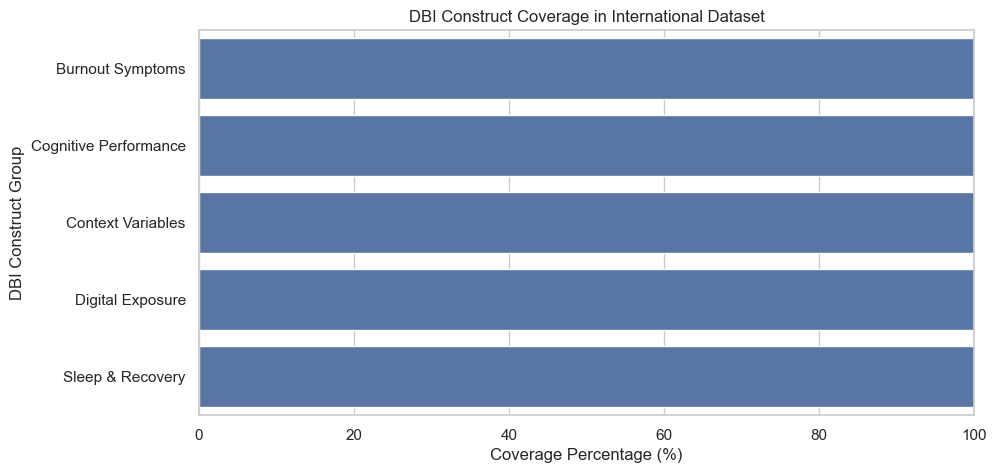

In [14]:
# Visualize DBI coverage

plt.figure(figsize=(10, 5))

sns.barplot(
    data=dbi_coverage_summary,
    x="coverage_percent",
    y="construct_group"
)

plt.title("DBI Construct Coverage in International Dataset")
plt.xlabel("Coverage Percentage (%)")
plt.ylabel("DBI Construct Group")
plt.xlim(0, 100)
plt.show()

## 6. Missing Values Analysis

Missing Values là một trong những vấn đề phổ biến nhất trong dữ liệu thực tế.

Phần này nhằm:

- Xác định các biến có dữ liệu thiếu.
- Đánh giá tỷ lệ thiếu dữ liệu.
- Hỗ trợ lựa chọn chiến lược xử lý ở bước Cleaning & Preprocessing.

Chưa thực hiện bất kỳ xử lý nào trong notebook này.

In [15]:
# Missing values summary

missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

display(missing_values)

,missing_count,missing_percent
sleep_hours,100000,2.0
social_media_hours,100000,2.0
deep_work_hours,100000,2.0
motivation_level,100000,2.0
mental_state,0,0.0
work_satisfaction,0,0.0
burnout_risk,0,0.0
emotional_exhaustion,0,0.0
mental_fatigue,0,0.0
sleep_quality,0,0.0


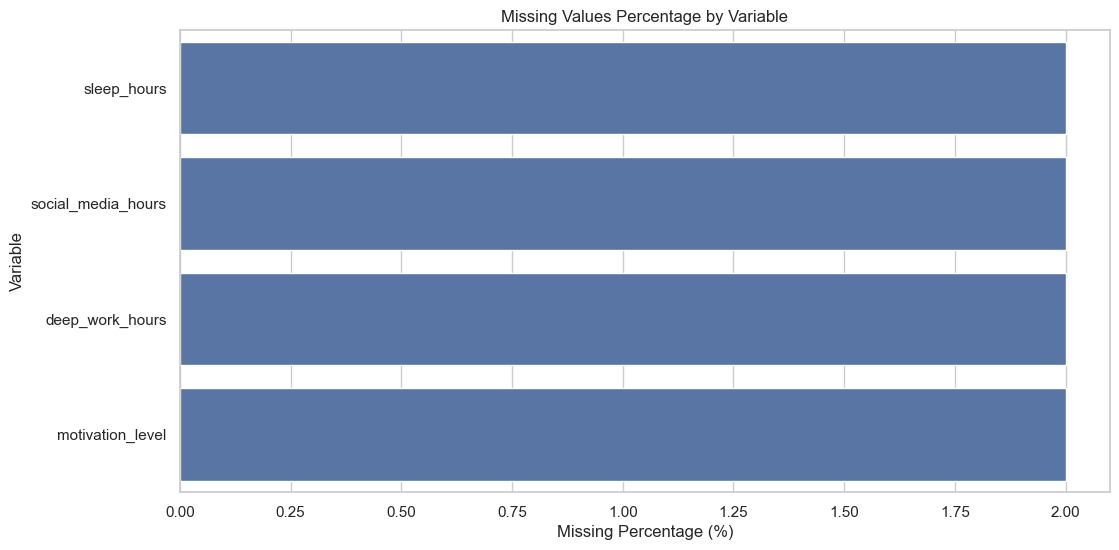

In [16]:
# Visualize missing values

missing_plot = missing_values[missing_values["missing_count"] > 0]

if missing_plot.empty:
    print("No missing values detected.")
else:
    plt.figure(figsize=(12, 6))
    
    sns.barplot(
        data=missing_plot.reset_index(),
        x="missing_percent",
        y="index"
    )
    
    plt.title("Missing Values Percentage by Variable")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Variable")
    plt.show()

## 7. Duplicate Analysis

Mục tiêu:

- Kiểm tra sự tồn tại của các bản ghi trùng lặp.
- Đánh giá ảnh hưởng của dữ liệu trùng lặp tới chất lượng dữ liệu.

Việc loại bỏ dữ liệu trùng lặp sẽ được thực hiện trong notebook Cleaning & Preprocessing.

In [17]:
# Duplicate analysis

duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

print("Number of duplicated rows:", duplicate_count)
print(f"Duplicated rows percentage: {duplicate_percent:.4f}%")

if duplicate_count > 0:
    print("\nSample duplicated rows:")
    display(df[df.duplicated()].head())
else:
    print("No duplicated rows detected.")

Number of duplicated rows: 0
Duplicated rows percentage: 0.0000%
No duplicated rows detected.


## 8. Data Quality Assessment

Phần này tổng hợp các vấn đề chất lượng dữ liệu bao gồm:

- Missing Values
- Duplicate Records
- Data Type Issues
- Low Variation Variables

Kết quả sẽ được sử dụng làm cơ sở cho các quyết định tiền xử lý dữ liệu ở bước tiếp theo.

In [18]:
# Data quality report

data_quality_report = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean() * 100).round(4).values,
    "unique_values": df.nunique().values,
    "duplicate_rows_total": duplicate_count
})

def assign_quality_flag(row):
    if row["missing_percent"] >= 50:
        return "High missing - review required"
    elif row["missing_percent"] > 0:
        return "Has missing values"
    elif row["unique_values"] <= 1:
        return "Low variation - review required"
    else:
        return "No immediate issue"

data_quality_report["preprocessing_note"] = data_quality_report.apply(assign_quality_flag, axis=1)

display(data_quality_report)

,column_name,data_type,missing_count,missing_percent,unique_values,duplicate_rows_total,preprocessing_note
user_id,user_id,int64,0,0.0,5000000,0,No immediate issue
age,age,int64,0,0.0,42,0,No immediate issue
occupation,occupation,object,0,0.0,7,0,No immediate issue
work_mode,work_mode,object,0,0.0,3,0,No immediate issue
device_usage_type,device_usage_type,object,0,0.0,3,0,No immediate issue
daily_screen_time,daily_screen_time,float64,0,0.0,171,0,No immediate issue
social_media_hours,social_media_hours,float64,100000,2.0,121,0,Has missing values
doomscrolling_duration,doomscrolling_duration,float64,0,0.0,80,0,No immediate issue
app_switch_frequency,app_switch_frequency,int64,0,0.0,240,0,No immediate issue
notification_count,notification_count,int64,0,0.0,380,0,No immediate issue


## 9. Descriptive Statistics

Phần này cung cấp các thống kê mô tả cơ bản:

- Mean
- Median
- Standard Deviation
- Minimum
- Maximum

Mục tiêu:

- Hiểu phạm vi giá trị của các biến.
- Phát hiện các giá trị bất thường tiềm năng.
- Hỗ trợ bước phân tích khám phá dữ liệu.

In [19]:
# Descriptive statistics for numerical variables

print("Descriptive statistics for numerical variables:")
display(df[numerical_columns].describe().T)

Descriptive statistics for numerical variables:


,count,mean,std,min,25%,50%,75%,max
user_id,5000000.0,2.500000e+06,1.443376e+06,1.0,1250000.75,2500000.5,3750000.25,5000000.0
age,5000000.0,3.849935e+01,1.212046e+01,18.0,28.00,38.0,49.00,59.0
daily_screen_time,5000000.0,8.001010e+00,2.494805e+00,1.0,6.30,8.0,9.70,18.0
social_media_hours,4900000.0,3.517651e+00,1.759434e+00,0.0,2.30,3.5,4.70,12.0
doomscrolling_duration,5000000.0,1.834645e+00,1.132208e+00,0.0,1.00,1.8,2.60,7.9
app_switch_frequency,5000000.0,1.294981e+02,6.928145e+01,10.0,69.00,129.0,190.00,249.0
notification_count,5000000.0,2.094380e+02,1.096646e+02,20.0,114.00,209.0,304.00,399.0
smartphone_unlocks,5000000.0,1.570431e+02,8.228162e+01,15.0,86.00,157.0,228.00,299.0
late_night_device_usage,5000000.0,6.499932e-01,4.769718e-01,0.0,0.00,1.0,1.00,1.0
focus_sessions,5000000.0,4.500512e+00,2.872723e+00,0.0,2.00,5.0,7.00,9.0


In [20]:
# Additional numerical summary

basic_stats = df[numerical_columns].agg(["mean", "median", "std", "min", "max"]).T

display(basic_stats)

,mean,median,std,min,max
user_id,2.500000e+06,2500000.5,1.443376e+06,1.0,5000000.0
age,3.849935e+01,38.0,1.212046e+01,18.0,59.0
daily_screen_time,8.001010e+00,8.0,2.494805e+00,1.0,18.0
social_media_hours,3.517651e+00,3.5,1.759434e+00,0.0,12.0
doomscrolling_duration,1.834645e+00,1.8,1.132208e+00,0.0,7.9
app_switch_frequency,1.294981e+02,129.0,6.928145e+01,10.0,249.0
notification_count,2.094380e+02,209.0,1.096646e+02,20.0,399.0
smartphone_unlocks,1.570431e+02,157.0,8.228162e+01,15.0,299.0
late_night_device_usage,6.499932e-01,1.0,4.769718e-01,0.0,1.0
focus_sessions,4.500512e+00,5.0,2.872723e+00,0.0,9.0


In [21]:
# Descriptive statistics for categorical variables

if categorical_columns:
    print("Descriptive statistics for categorical variables:")
    display(df[categorical_columns].describe().T)
else:
    print("No categorical variables detected.")

Descriptive statistics for categorical variables:


,count,unique,top,freq
occupation,5000000,7,Freelancer,715500
work_mode,5000000,3,Remote,2250774
device_usage_type,5000000,3,Balanced,1749883
mental_state,5000000,4,Distracted,1500163
productivity_category,5000000,3,High,2374159


## 10. Initial Distribution Snapshot

Phần này quan sát sơ bộ phân phối của một số biến quan trọng liên quan đến Digital Burnout.

Mục tiêu:

- Hiểu hình dạng phân phối dữ liệu.
- Phát hiện sự lệch phân phối.
- Nhận diện các dấu hiệu bất thường ban đầu.

Kết quả chỉ mang tính mô tả và không được sử dụng để kết luận học thuật.

In [22]:
# Select important variables for initial distribution snapshot

selected_distribution_columns = [
    "burnout_risk",
    "productivity_score",
    "daily_screen_time",
    "social_media_hours",
    "sleep_hours",
    "emotional_exhaustion",
    "stress_level",
    "mental_fatigue"
]

available_distribution_columns = [
    col for col in selected_distribution_columns if col in df.columns
]

print("Available columns for initial distribution snapshot:")
print(available_distribution_columns)

Available columns for initial distribution snapshot:
['burnout_risk', 'productivity_score', 'daily_screen_time', 'social_media_hours', 'sleep_hours', 'emotional_exhaustion', 'stress_level', 'mental_fatigue']


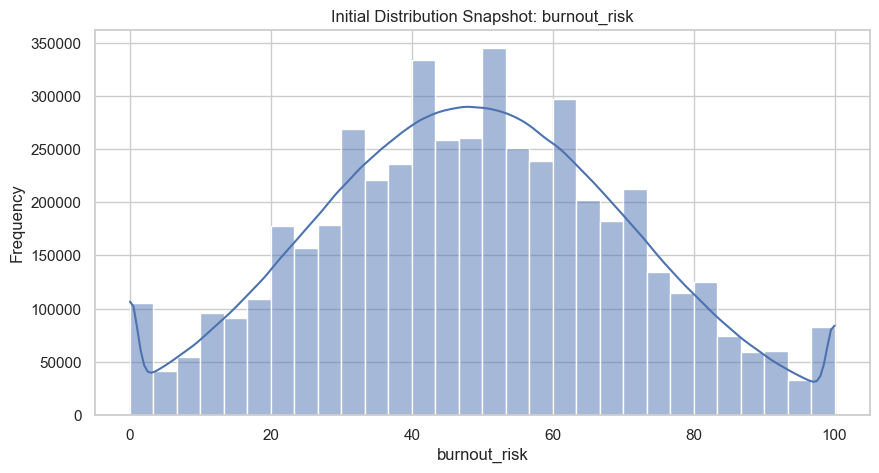

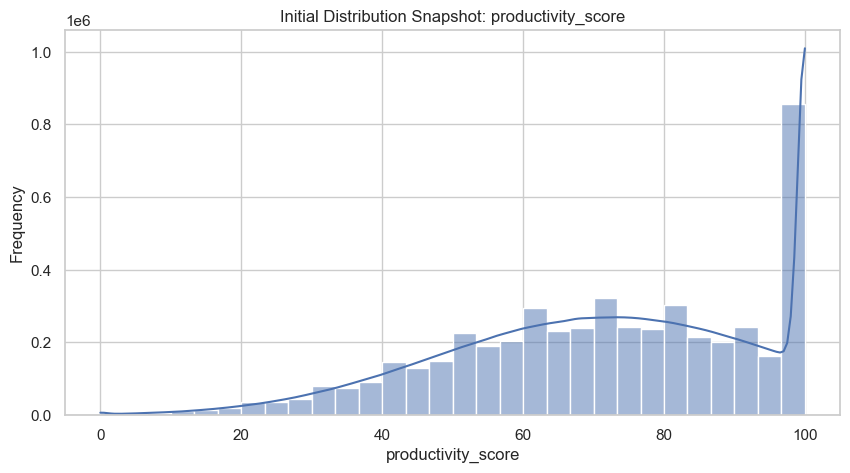

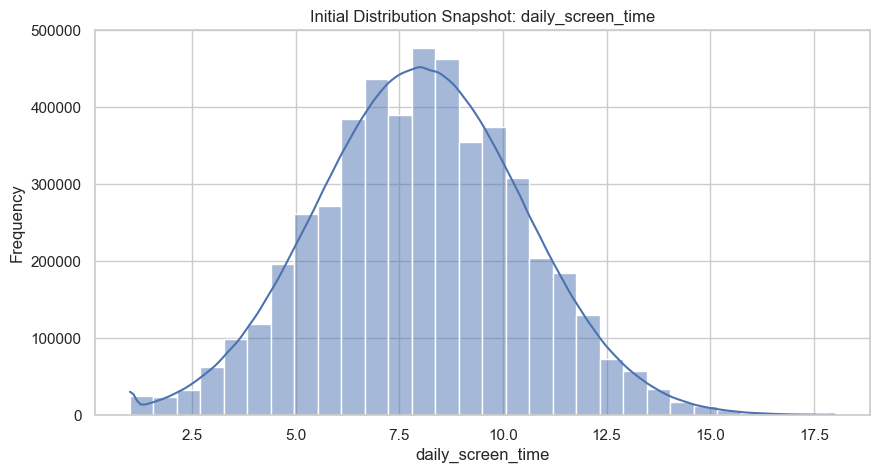

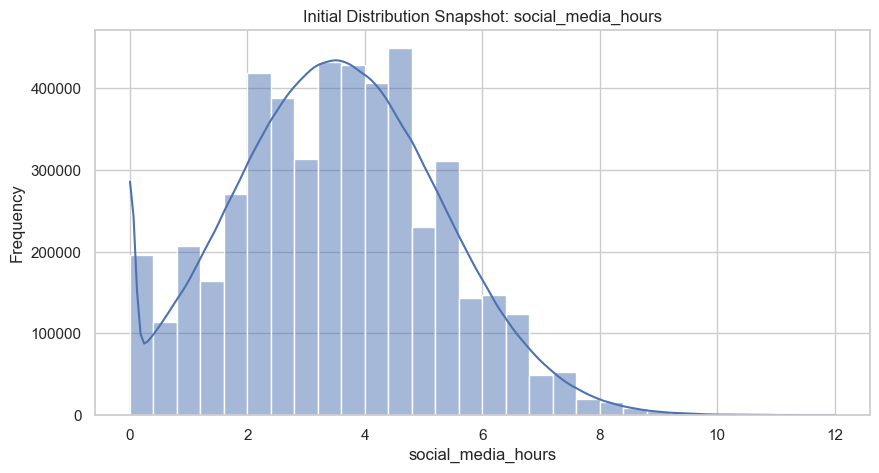

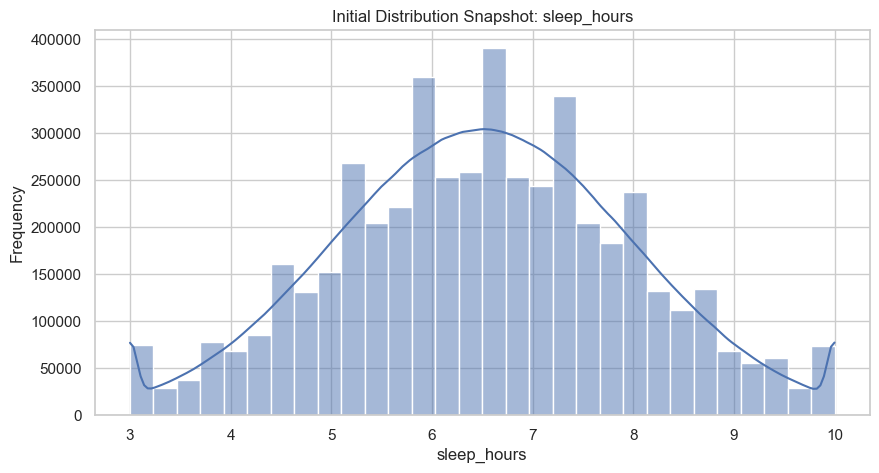

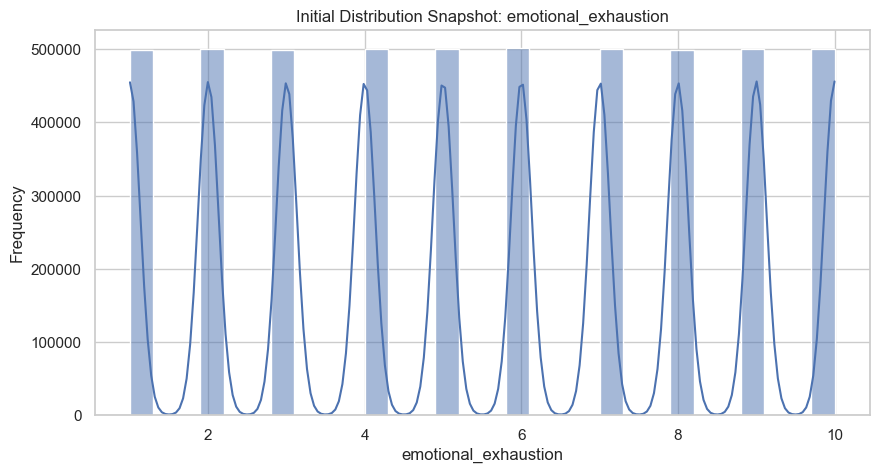

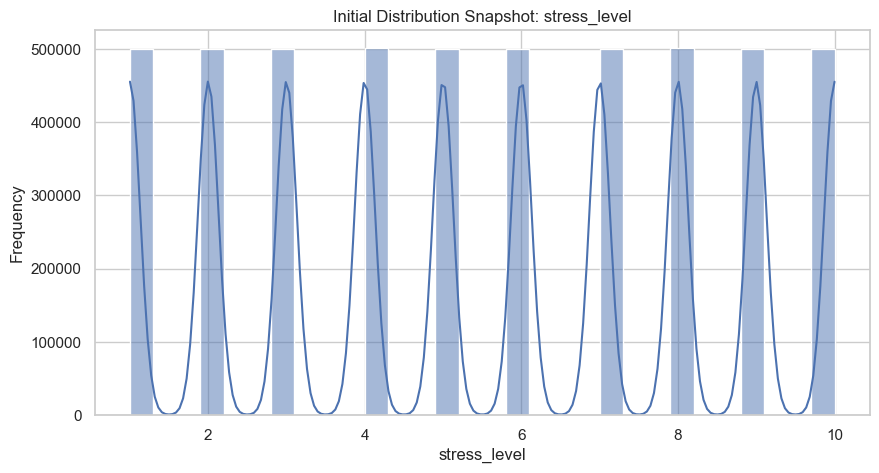

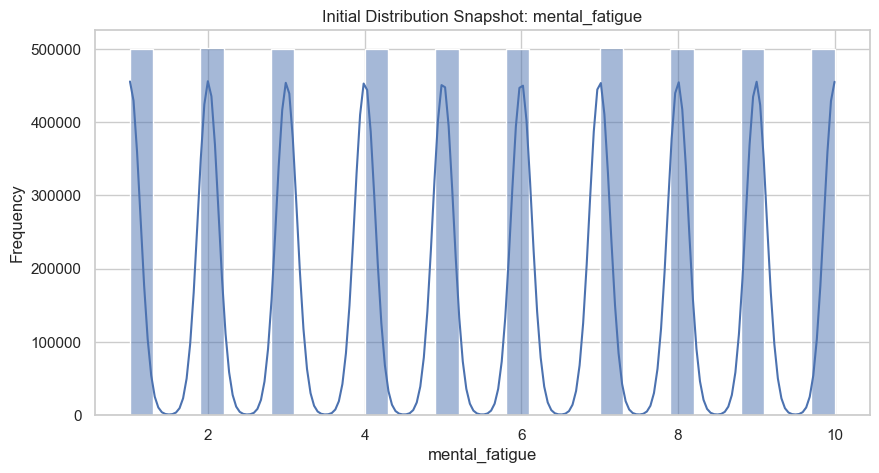

In [23]:
# Plot initial distributions

for col in available_distribution_columns:
    plt.figure(figsize=(10, 5))
    
    sns.histplot(df[col], kde=True, bins=30)
    
    plt.title(f"Initial Distribution Snapshot: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 11. Initial Outlier Snapshot

Boxplot được sử dụng để quan sát sơ bộ sự xuất hiện của các giá trị ngoại lai.

Lưu ý:

Việc quyết định giữ hay loại bỏ outlier không được thực hiện trong notebook này.

Các quyết định xử lý outlier sẽ được thực hiện trong bước Cleaning & Preprocessing.

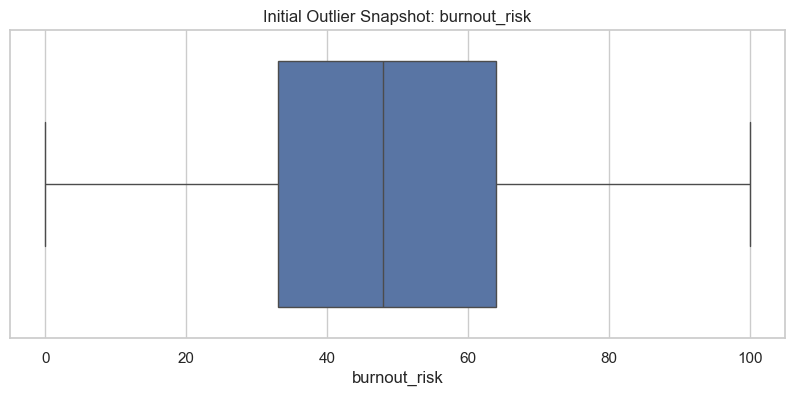

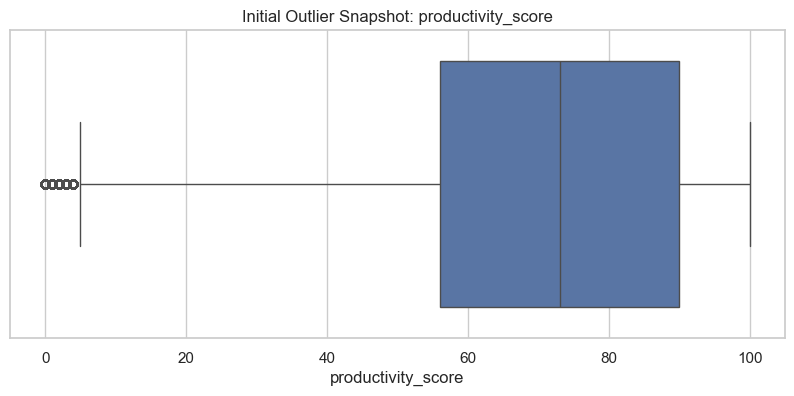

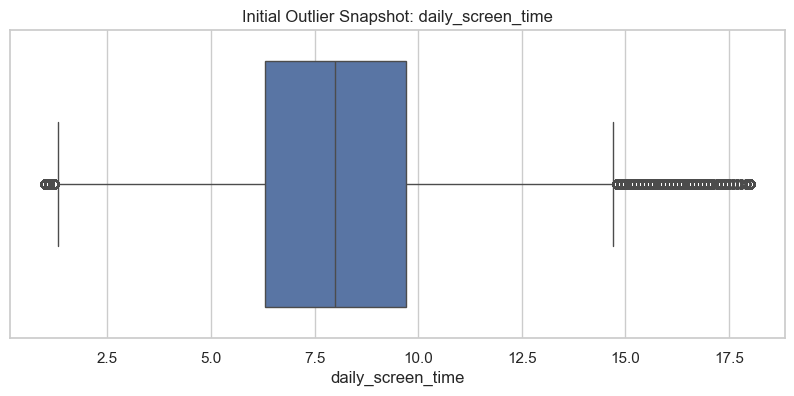

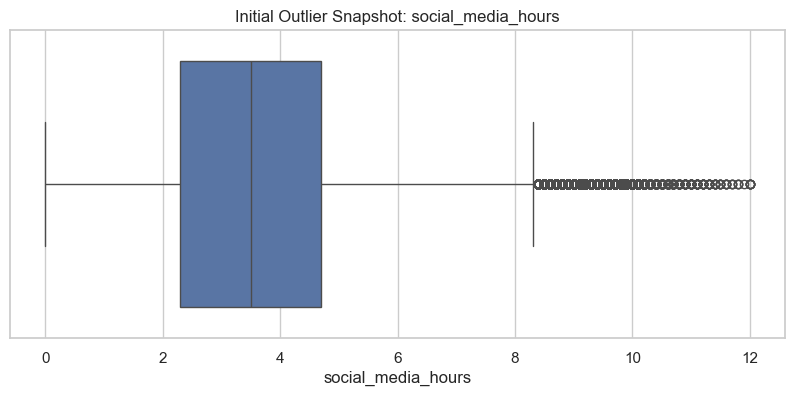

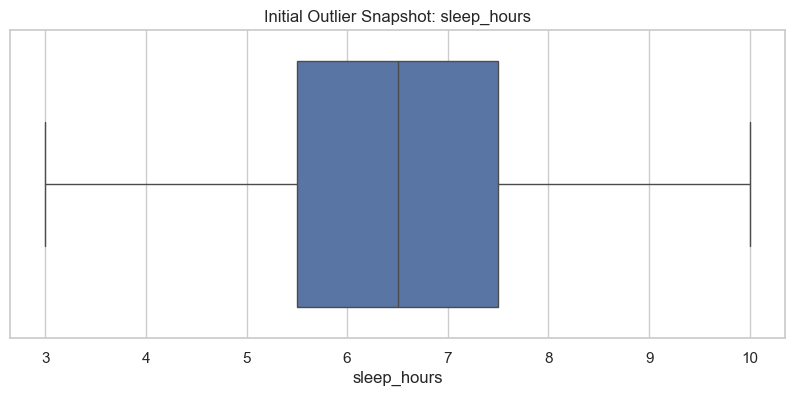

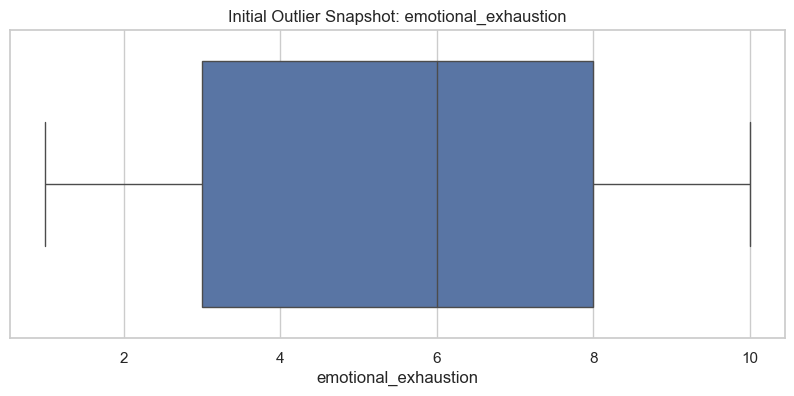

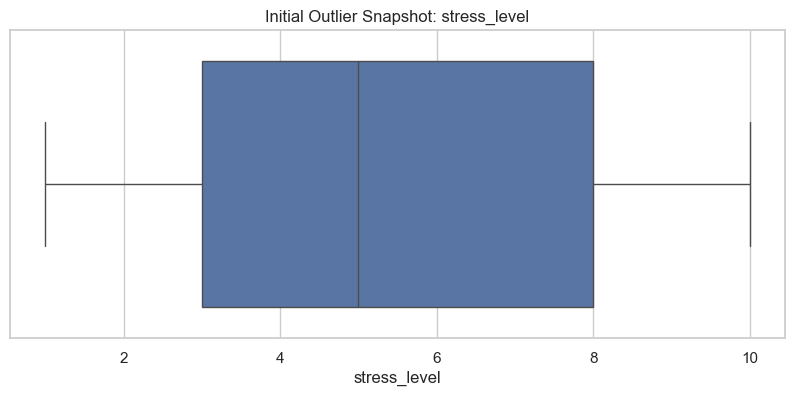

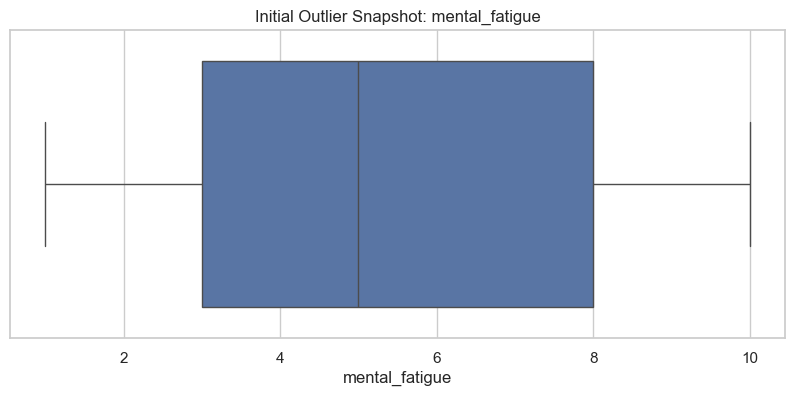

In [24]:
# Initial outlier snapshot using boxplots

for col in available_distribution_columns:
    plt.figure(figsize=(10, 4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Initial Outlier Snapshot: {col}")
    plt.xlabel(col)
    plt.show()

## 12. Initial Construct Consistency Snapshot

Phần này chỉ nhằm quan sát sơ bộ mối liên hệ giữa các biến thuộc nhóm Burnout Symptoms:

- burnout_risk
- emotional_exhaustion
- stress_level
- mental_fatigue

Mục tiêu:

- Kiểm tra các biến có xuất hiện mối liên hệ ban đầu hay không.
- Hỗ trợ định hướng cho bước Feature Validation.

Lưu ý:

Kết quả tại đây không được sử dụng để:

- Xác nhận chỉ báo hợp lệ.
- Xác nhận giả thuyết nghiên cứu.
- Lựa chọn biến cho mô hình.

Các kiểm định thống kê chính thức sẽ được thực hiện trong notebook:

04_feature_validation.ipynb

,burnout_risk,emotional_exhaustion,stress_level,mental_fatigue
burnout_risk,1.000000,0.511981,0.382824,-0.000124
emotional_exhaustion,0.511981,1.000000,0.000478,0.000216
stress_level,0.382824,0.000478,1.000000,-0.000555
mental_fatigue,-0.000124,0.000216,-0.000555,1.000000


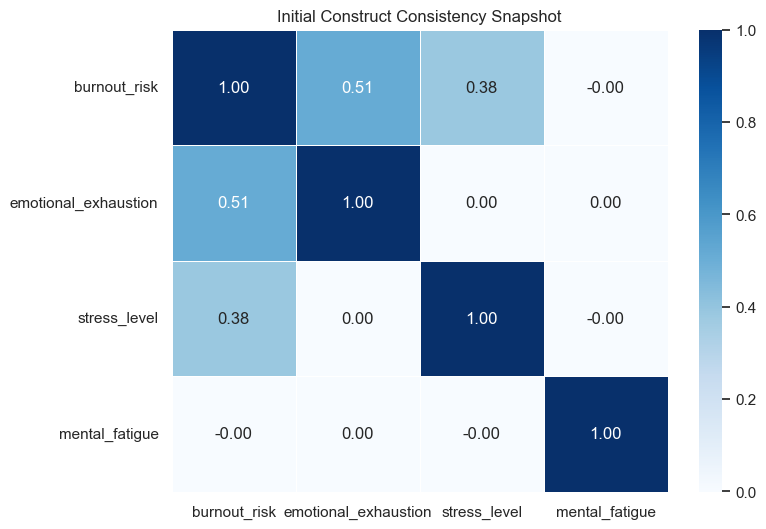

In [25]:
# Initial construct consistency snapshot

construct_snapshot_columns = [
    "burnout_risk",
    "emotional_exhaustion",
    "stress_level",
    "mental_fatigue"
]

available_construct_snapshot_columns = [
    col for col in construct_snapshot_columns if col in df.columns
]

if len(available_construct_snapshot_columns) >= 2:
    construct_snapshot_corr = df[available_construct_snapshot_columns].corr()

    display(construct_snapshot_corr)

    plt.figure(figsize=(8, 6))
    
    sns.heatmap(
        construct_snapshot_corr,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cmap="Blues"
    )

    plt.title("Initial Construct Consistency Snapshot")
    plt.show()
else:
    print("Not enough construct variables available for initial consistency snapshot.")

## 13. PreEDA Outputs

Kết quả đầu ra của notebook bao gồm:

1. Dataset Overview
2. Variable Classification
3. DBI Variable Inventory
4. DBI Coverage Summary
5. Missing Value Report
6. Duplicate Report
7. Data Quality Assessment
8. Descriptive Statistics
9. Initial Distribution Snapshot
10. Initial Construct Consistency Snapshot


In [26]:
# PreEDA output summary

preeda_output_summary = pd.DataFrame({
    "output": [
        "Dataset Overview",
        "Variable Classification",
        "DBI Variable Inventory",
        "DBI Coverage Summary",
        "Missing Value Report",
        "Duplicate Report",
        "Data Quality Assessment",
        "Descriptive Statistics",
        "Initial Distribution Snapshot",
        "Initial Construct Consistency Snapshot"
    ],
    "purpose": [
        "Understand dataset size and structure",
        "Separate numerical and categorical variables",
        "Map available variables to preliminary DBI construct groups",
        "Assess whether dataset covers DBI dimensions",
        "Support missing value handling decisions",
        "Support duplicate handling decisions",
        "Identify preprocessing issues",
        "Understand basic ranges and central tendency",
        "Observe variable distributions only",
        "Check preliminary construct availability and consistency only"
    ],
    "used_for_next_stage": [
        "Cleaning & Preprocessing",
        "Cleaning & Preprocessing",
        "DBI Development and Feature Validation",
        "DBI Development",
        "Cleaning & Preprocessing",
        "Cleaning & Preprocessing",
        "Cleaning & Preprocessing",
        "EDA",
        "EDA",
        "Feature Validation"
    ]
})

display(preeda_output_summary)

,output,purpose,used_for_next_stage
0,Dataset Overview,Understand dataset size and structure,Cleaning & Preprocessing
1,Variable Classification,Separate numerical and categorical variables,Cleaning & Preprocessing
2,DBI Variable Inventory,Map available variables to preliminary DBI con...,DBI Development and Feature Validation
3,DBI Coverage Summary,Assess whether dataset covers DBI dimensions,DBI Development
4,Missing Value Report,Support missing value handling decisions,Cleaning & Preprocessing
5,Duplicate Report,Support duplicate handling decisions,Cleaning & Preprocessing
6,Data Quality Assessment,Identify preprocessing issues,Cleaning & Preprocessing
7,Descriptive Statistics,Understand basic ranges and central tendency,EDA
8,Initial Distribution Snapshot,Observe variable distributions only,EDA
9,Initial Construct Consistency Snapshot,Check preliminary construct availability and c...,Feature Validation


## 14. Final PreEDA Summary

Phần này tổng hợp lại các phát hiện chính sau khi khảo sát sơ bộ dữ liệu.

Mục tiêu:

- Tóm tắt quy mô dữ liệu.
- Tóm tắt chất lượng dữ liệu.
- Tóm tắt mức độ bao phủ các biến liên quan DBI.
- Xác định notebook tiếp theo cần xử lý gì.

Phần này không đưa ra kết luận học thuật cuối cùng.

In [27]:
# Final PreEDA summary

print("PRE-EDA SUMMARY")
print("-" * 60)

print(f"1. Dataset size: {df.shape[0]:,} rows and {df.shape[1]} columns.")
print(f"2. Numerical variables: {len(numerical_columns)}")
print(f"3. Categorical variables: {len(categorical_columns)}")

total_missing = df.isnull().sum().sum()
print(f"4. Total missing values: {total_missing:,}")

print(f"5. Duplicated rows: {duplicate_count:,}")

available_dbi_variables = dbi_inventory["available_in_dataset"].sum()
total_dbi_variables = len(dbi_inventory)

print(f"6. Available DBI-related variables: {available_dbi_variables}/{total_dbi_variables}")

if "burnout_risk" in df.columns:
    print(f"7. Mean burnout_risk: {df['burnout_risk'].mean():.3f}")

if "productivity_score" in df.columns:
    print(f"8. Mean productivity_score: {df['productivity_score'].mean():.3f}")

if "daily_screen_time" in df.columns:
    print(f"9. Mean daily_screen_time: {df['daily_screen_time'].mean():.3f}")

if "sleep_hours" in df.columns:
    print(f"10. Mean sleep_hours: {df['sleep_hours'].mean():.3f}")

print("-" * 60)
print("This notebook stops at PreEDA.")
print("No cleaning, feature validation, modeling, or interpretability is performed here.")

PRE-EDA SUMMARY
------------------------------------------------------------
1. Dataset size: 5,000,000 rows and 34 columns.
2. Numerical variables: 29
3. Categorical variables: 5
4. Total missing values: 400,000
5. Duplicated rows: 0
6. Available DBI-related variables: 22/22
7. Mean burnout_risk: 48.584
8. Mean productivity_score: 71.444
9. Mean daily_screen_time: 8.001
10. Mean sleep_hours: 6.501
------------------------------------------------------------
This notebook stops at PreEDA.
No cleaning, feature validation, modeling, or interpretability is performed here.
